Chart successfully saved to ablation_7day_comparison.png


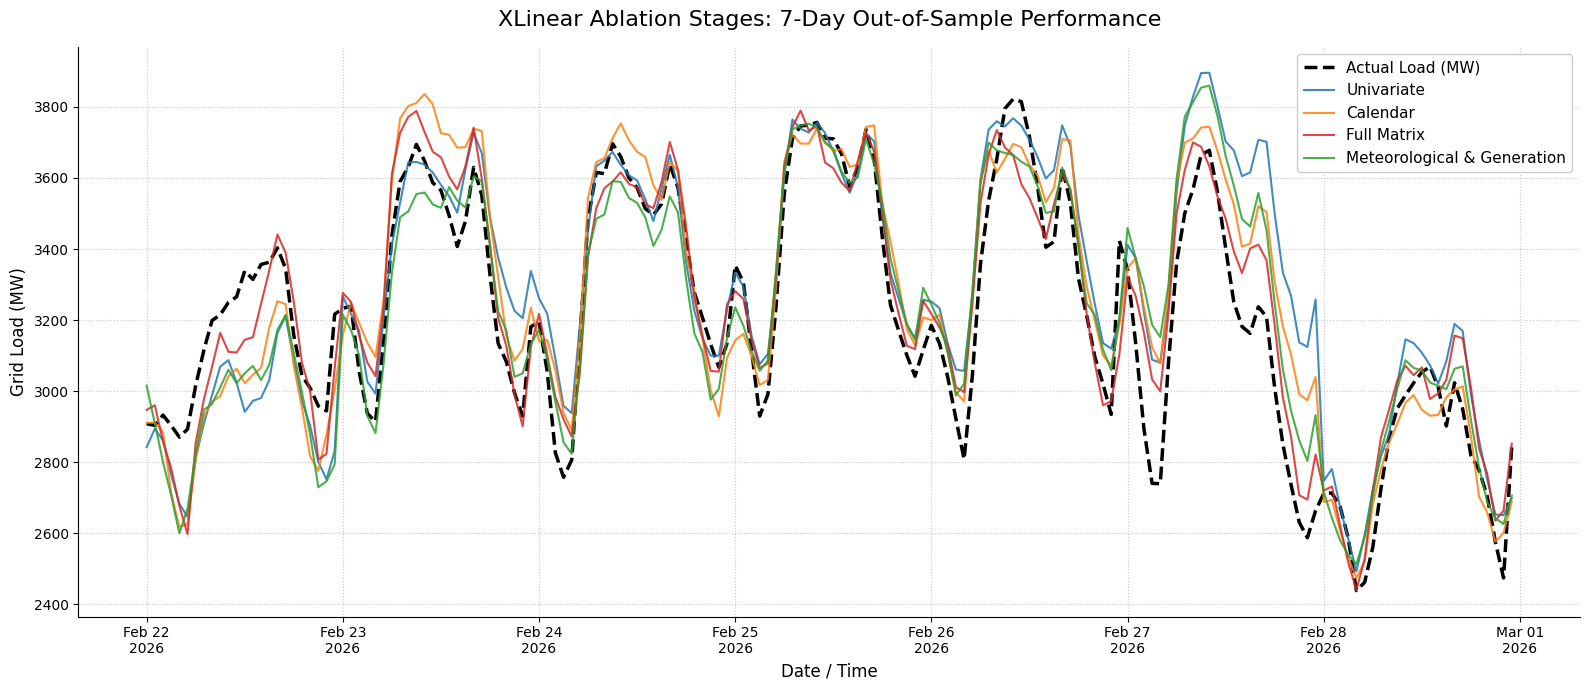

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# XLinear result files
file_names = [
    'xlinear_results_uni.csv',
    'xlinear_results_calendar.csv',
    'xlinear_results_wea_gen.csv',
    'xlinear_results_full.csv'
]

df_list = [pd.read_csv(f) for f in file_names]
df = pd.concat(df_list, ignore_index=True)

# Just in-case
df['ds'] = pd.to_datetime(df['ds'])

# Last 7-days
max_date = df['ds'].max()
start_date = max_date - pd.Timedelta(days=7)
df_last_7_days = df[df['ds'] > start_date].copy()

df_last_7_days = df_last_7_days.sort_values(by='ds')

# Plot
plt.figure(figsize=(16, 7))

# Plot actual load
# y should be identical in all so we can use the first one
df_actual = df_last_7_days[df_last_7_days['Model_ID'] == df_last_7_days['Model_ID'].unique()[0]]
plt.plot(df_actual['ds'], df_actual['y'], 
         label='Actual Load (MW)', color='black', linewidth=2.5, linestyle='--')

# Plot the 4 Model Forecasts
color_map = {
    'uni': '#1f77b4',       #  Blue
    'calendar': '#ff7f0e',  #  Orange
    'wea_gen': '#2ca02c',   #  Green
    'full': '#d62728'       #  Red
}

for model_id in df_last_7_days['Model_ID'].unique():
    model_data = df_last_7_days[df_last_7_days['Model_ID'] == model_id]
    if model_id == 'uni': model_name = 'Univariate'
    if model_id == 'calendar': model_name = 'Calendar'
    if model_id == 'full': model_name = 'Full Matrix'
    if model_id == 'wea_gen': model_name = 'Meteorological & Generation'

    # Fetch color if it matches our map, otherwise let matplotlib pick
    color = color_map.get(model_id, None)
    
    plt.plot(model_data['ds'], model_data['Forecast_MW'], 
             label=f'{model_name}', color=color, linewidth=1.5, alpha=0.85)

# Formatting
plt.title('XLinear Ablation Stages: 7-Day Out-of-Sample Performance', fontsize=16, pad=15)
plt.xlabel('Date / Time', fontsize=12)
plt.ylabel('Grid Load (MW)', fontsize=12)

# X-axis daily ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%Y')) # e.g., Jan 04\n2026
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

#  Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=11, framealpha=1.0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Export
output_filename = 'ablation_7day_comparison.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Chart successfully saved to {output_filename}")

plt.show()

In [2]:
#Metrics Table for Ablation Study
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

df_list = [pd.read_csv(f) for f in file_names]
df_master = pd.concat(df_list, ignore_index=True)

# Function to calculate metrics
def calculate_metrics(group):
    y_true = group['y']
    y_pred = group['Forecast_MW']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return pd.Series({
        'MAE (MW)': f"{mae:.2f}",
        'RMSE (MW)': f"{rmse:.2f}",
        'MAPE (%)': f"{mape:.3f}"
    })

# Group by Model_ID and apply
performance_table = df_master.groupby('Model_ID').apply(calculate_metrics).reset_index()

stage_order = ['uni', 'calendar', 'wea_gen', 'full']

# Convert Model_ID to a categorical type to enforce custom sorting
performance_table['Model_ID'] = pd.Categorical(performance_table['Model_ID'], categories=stage_order, ordered=True)
performance_table = performance_table.sort_values('Model_ID').reset_index(drop=True)

# 5. Rename column for presentation
performance_table.rename(columns={'Model_ID': 'Ablation Stage'}, inplace=True)

performance_table

,Ablation Stage,MAE (MW),RMSE (MW),MAPE (%)
0,uni,146.16,197.31,4.414
1,calendar,133.37,177.78,3.994
2,wea_gen,128.00,184.21,3.889
3,full,117.15,177.00,3.565


In [3]:
import pandas as pd

df_entso = pd.read_csv('GUI_TOTAL_LOAD_DAYAHEAD_202601010000-202701010000.csv')
df_entso = df_entso.rename(columns={'MTU (CET/CEST)':'ds'})

In [4]:
import numpy as np

numeric_cols = ['Actual Total Load (MW)', 'Day-ahead Total Load Forecast (MW)']

for col in numeric_cols:
    df_entso[col] = pd.to_numeric(df_entso[col], errors='coerce').astype('float32')
# 2. Extract the columns
actuals = df_entso['Actual Total Load (MW)']
forecasts = df_entso['Day-ahead Total Load Forecast (MW)']

# 3. Calculate the Absolute Percentage Error (APE) per row
df_entso['absolute_error'] = np.abs(actuals - forecasts)
df_entso['ape'] = df_entso['absolute_error'] / actuals

# 4. Calculate the Mean (MAPE) and convert to percentage
entsoe_mape = df_entso['ape'].mean() * 100

print(f"=========================================================")
print(f"Official ENTSO-E Day-Ahead Forecast MAPE: {entsoe_mape:.3f}%")
print(f"=========================================================")

Official ENTSO-E Day-Ahead Forecast MAPE: 2.978%


In [5]:
import pandas as pd

df_entso['ds'] = df_entso['ds'].str.split(' - ').str[0]
# Remove the trailing timezone in parentheses
df_entso['ds'] = df_entso['ds'].str.replace(r'\s*\([^)]+\)', '', regex=True)

# Convert to native datetime
df_entso['ds'] = pd.to_datetime(df_entso['ds'], format='%d/%m/%Y %H:%M')

Vectorized comparison plot compiled and saved as 'model_comparison_holiday_week.png'.


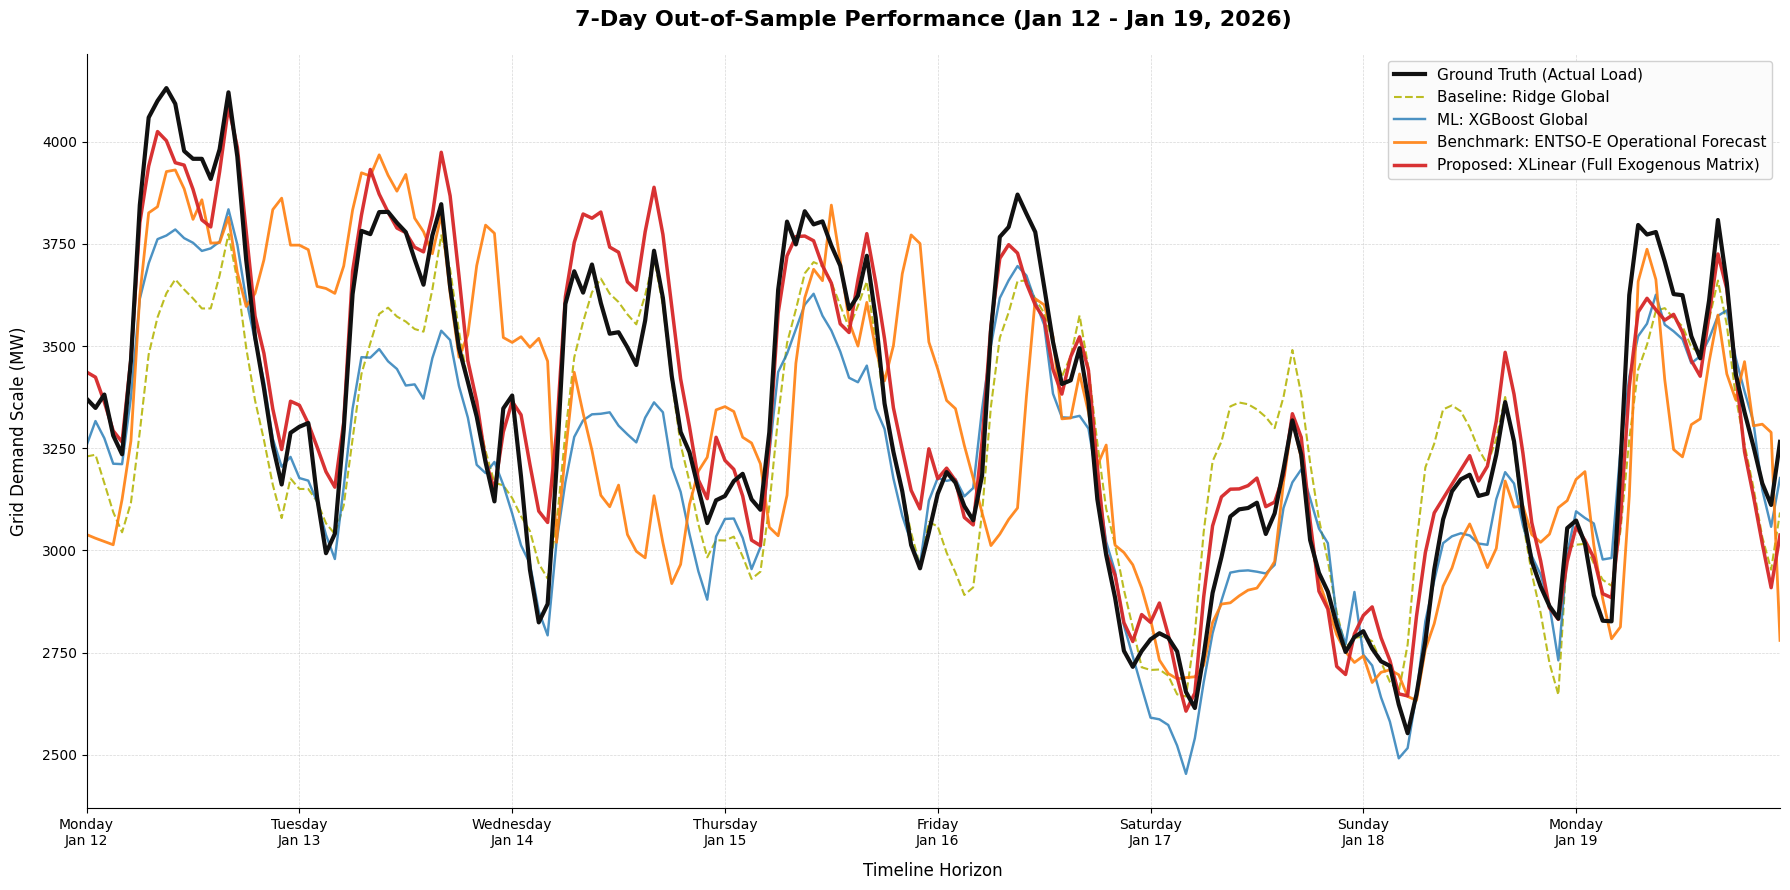

In [ ]:
# ==========================================
# DATA INGESTION and DST CORRECTION
# ==========================================

# XGBoost results
xgb_expert = pd.read_csv('xgboost_24expert_results.csv')
xgb_global = pd.read_csv('xgboost_baseline_results.csv')

xgb_expert['ds'] = pd.to_datetime(xgb_expert['timestamp']).dt.tz_localize(None)
xgb_global['ds'] = pd.to_datetime(xgb_global['timestamp']).dt.tz_localize(None)

xgb_expert = xgb_expert.drop_duplicates(subset=['ds'])
xgb_global = xgb_global.drop_duplicates(subset=['ds'])

# Ridge result
ridge = pd.read_csv('ridge_global_results.csv')
ridge_time_col = 'timestamp' if 'timestamp' in ridge.columns else 'ds'
ridge['ds'] = pd.to_datetime(ridge[ridge_time_col]).dt.tz_localize(None)
ridge = ridge.drop_duplicates(subset=['ds'])

# XLinear final result
xlin = pd.read_csv('xlinear_results_full.csv')
xlin['ds'] = pd.to_datetime(xlin['ds']).dt.tz_localize(None)
xlin = xlin.drop_duplicates(subset=['ds'])

# ENTSOE Benchmark
df_entsoe_clean = df_entso.copy()
df_entsoe_clean = df_entsoe_clean[df_entsoe_clean['Area'].str.contains('DK1', na=False)].copy()
df_entsoe_clean['ds'] = pd.to_datetime(df_entsoe_clean['ds']).dt.tz_localize(None)

#DST alignment for Entsoe
df_entsoe_clean['ds'] = df_entsoe_clean['ds'] - pd.Timedelta(hours=1)
# -------------------------------------
df_entsoe_clean = df_entsoe_clean.drop_duplicates(subset=['ds'])

#===========================
# Combined DF
#===========================
df_master = xgb_global[['ds', 'Actual']].copy()
df_master.rename(columns={'Actual': 'Actual_Load'}, inplace=True)

# SNaive
df_master['SNaive_Forecast'] = df_master['Actual_Load'].shift(168)

# ==========================================
# Merging DFs
# ==========================================
df_master = df_master.merge(xgb_expert[['ds', 'XGB_Prediction']], on='ds', how='left').rename(columns={'XGB_Prediction': 'XGB_24Expert'})
df_master = df_master.merge(xgb_global[['ds', 'XGB_Prediction']], on='ds', how='left').rename(columns={'XGB_Prediction': 'XGB_Global'})
df_master = df_master.merge(ridge[['ds', 'Ridge_Prediction']], on='ds', how='left')
df_master = df_master.merge(xlin[['ds', 'Forecast_MW']], on='ds', how='left').rename(columns={'Forecast_MW': 'XLinear_Full'})
df_master = df_master.merge(df_entsoe_clean[['ds', 'Day-ahead Total Load Forecast (MW)']], on='ds', how='left').rename(columns={'Day-ahead Total Load Forecast (MW)': 'ENTSOE_Forecast'})

# ==========================================
# Picking a week
# ==========================================

start_window = pd.to_datetime('2026-01-12 00:00:00')
end_window = pd.to_datetime('2026-01-19 23:00:00')

df_plot = df_master[(df_master['ds'] >= start_window) & (df_master['ds'] <= end_window)].copy()
df_plot.sort_values(by='ds', inplace=True)

# ==========================================
# Plotting
# ==========================================
plt.figure(figsize=(18, 9))

# Ground Truth
plt.plot(df_plot['ds'], df_plot['Actual_Load'], 
         label='Ground Truth (Actual Load)', color='#111111', linewidth=3.0, zorder=10)

# Ridge
plt.plot(df_plot['ds'], df_plot['Ridge_Prediction'], 
         label='Baseline: Ridge Global', color='#bcbd22', linewidth=1.5, linestyle='--')

# XGBoost
plt.plot(df_plot['ds'], df_plot['XGB_Global'], 
         label='ML: XGBoost Global', color='#1f77b4', linewidth=1.75, alpha=0.8)

# Benchmark and XLin
plt.plot(df_plot['ds'], df_plot['ENTSOE_Forecast'], 
         label='Benchmark: ENTSO-E Operational Forecast', color='#ff7f0e', linewidth=2.0, alpha=0.9)
plt.plot(df_plot['ds'], df_plot['XLinear_Full'], 
         label='Proposed: XLinear (Full Exogenous Matrix)', color='#d62728', linewidth=2.5, alpha=0.95)

# Formatting
plt.title('7-Day Out-of-Sample Performance (Jan 12 - Jan 19, 2026)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Timeline Horizon', fontsize=12, labelpad=10)
plt.ylabel('Grid Demand Scale (MW)', fontsize=12, labelpad=10)


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%A\n%b %d'))
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper right', fontsize=11, framealpha=1.0, edgecolor='#d1d1d1', facecolor='#fbfbfb')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(start_window, end_window)

plt.tight_layout()
plt.savefig('model_comparison_normal_week.png', dpi=300, bbox_inches='tight')
print("Vectorized comparison plot compiled and saved as 'model_comparison_holiday_week.png'.")
plt.show()

In [7]:
# CREATING RESULTS TABLE

# ==========================================
# Spine creation
# ==========================================

df_spine = df_entso.copy()

df_spine = df_spine[df_spine['Area'].str.contains('DK1', na=False)].copy()
df_spine['ds'] = pd.to_datetime(df_spine['ds']).dt.tz_localize(None)

#DST alignment
df_spine['ds'] = df_spine['ds'] - pd.Timedelta(hours=1)
# ======================================

df_spine = df_spine.drop_duplicates(subset=['ds']).sort_values('ds').reset_index(drop=True)

df_spine.rename(columns={
    'Actual Total Load (MW)': 'Actual_Load',
    'Day-ahead Total Load Forecast (MW)': 'ENTSOE_Forecast'
}, inplace=True)

# Interpolation for small gaps
df_spine['Actual_Load'] = df_spine['Actual_Load'].interpolate(method='linear')
df_spine['ENTSOE_Forecast'] = df_spine['ENTSOE_Forecast'].interpolate(method='linear')

# SNaive
df_spine['SNaive_Forecast'] = df_spine['Actual_Load'].shift(168)

# ==========================================
# MODEL PREDICTIONS
# ==========================================

def load_and_clean_csv(file_path, pred_col_name, time_col='timestamp'):
    tmp = pd.read_csv(file_path)
    tmp['ds'] = pd.to_datetime(tmp[time_col]).dt.tz_localize(None)
    tmp = tmp.drop_duplicates(subset=['ds'])
    return tmp[['ds', pred_col_name]].copy()

xgb_global = load_and_clean_csv('xgboost_baseline_results.csv', 'XGB_Prediction', 'timestamp').rename(columns={'XGB_Prediction': 'XGB_Global'})
xgb_expert = load_and_clean_csv('xgboost_24expert_results.csv', 'XGB_Prediction', 'timestamp').rename(columns={'XGB_Prediction': 'XGB_24Expert'})
xlin       = load_and_clean_csv('xlinear_results_full.csv', 'Forecast_MW', 'ds').rename(columns={'Forecast_MW': 'XLinear_Full'})

ridge_raw = pd.read_csv('ridge_global_results.csv')
ridge_time_col = 'timestamp' if 'timestamp' in ridge_raw.columns else 'ds'
ridge = load_and_clean_csv('ridge_global_results.csv', 'Ridge_Prediction', ridge_time_col)

# ==========================================
# MERGE
# ==========================================

df_master_clean = df_spine[['ds', 'Actual_Load', 'SNaive_Forecast', 'ENTSOE_Forecast']].copy()

df_master_clean = df_master_clean.merge(xgb_expert, on='ds', how='left')
df_master_clean = df_master_clean.merge(xgb_global, on='ds', how='left')
df_master_clean = df_master_clean.merge(ridge, on='ds', how='left')
df_master_clean = df_master_clean.merge(xlin, on='ds', how='left')

# ==========================================
# Test boundary
# ==========================================
test_start = pd.to_datetime('2026-01-04 00:00:00')
test_end = pd.to_datetime('2026-02-28 23:00:00')

df_eval = df_master_clean[(df_master_clean['ds'] >= test_start) & (df_master_clean['ds'] <= test_end)].copy()

models_to_evaluate = {
    'Baseline: SNaive (t-168)': 'SNaive_Forecast',
    'Baseline: Ridge Global': 'Ridge_Prediction',
    'ML: XGBoost Global': 'XGB_Global',
    'ML: XGBoost 24-Expert': 'XGB_24Expert',
    'Deep Learning: XLinear Full': 'XLinear_Full',
    'Benchmark: ENTSO-E DAM': 'ENTSOE_Forecast'
}

final_results = []
for model_name, col_name in models_to_evaluate.items():
    valid_data = df_eval.dropna(subset=['Actual_Load', col_name])
    
    y_true = valid_data['Actual_Load']
    y_pred = valid_data[col_name]
    
    if len(y_true) > 0:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        
        final_results.append({
            'Architecture Tier': model_name,
            'Hours Evaluated': len(y_true),
            'MAE (MW)': f"{mae:.2f}",
            'RMSE (MW)': f"{rmse:.2f}",
            'MAPE (%)': f"{mape:.3f}"
        })

performance_df = pd.DataFrame(final_results)
performance_df

,Architecture Tier,Hours Evaluated,MAE (MW),RMSE (MW),MAPE (%)
0,Baseline: SNaive (t-168),1249,266.87,324.89,8.106
1,Baseline: Ridge Global,1344,174.48,248.74,5.355
2,ML: XGBoost Global,1344,181.09,246.15,5.464
3,ML: XGBoost 24-Expert,1344,215.96,281.00,6.431
4,Deep Learning: XLinear Full,1344,117.15,177.00,3.565
5,Benchmark: ENTSO-E DAM,1344,134.64,203.48,3.991


In [8]:
df_entso['error'] = df_entso['Actual Total Load (MW)']-df_entso['Day-ahead Total Load Forecast (MW)']

In [9]:
df_entso = df_entso.dropna()

<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Benedek\AppData\Local\Temp\ipykernel_8360\1199348037.py:49: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_title('Relative Performance Differential ($\Delta$ MAPE = ENTSO-E - XLinear)', fontsize=11, weight='bold', pad=10)


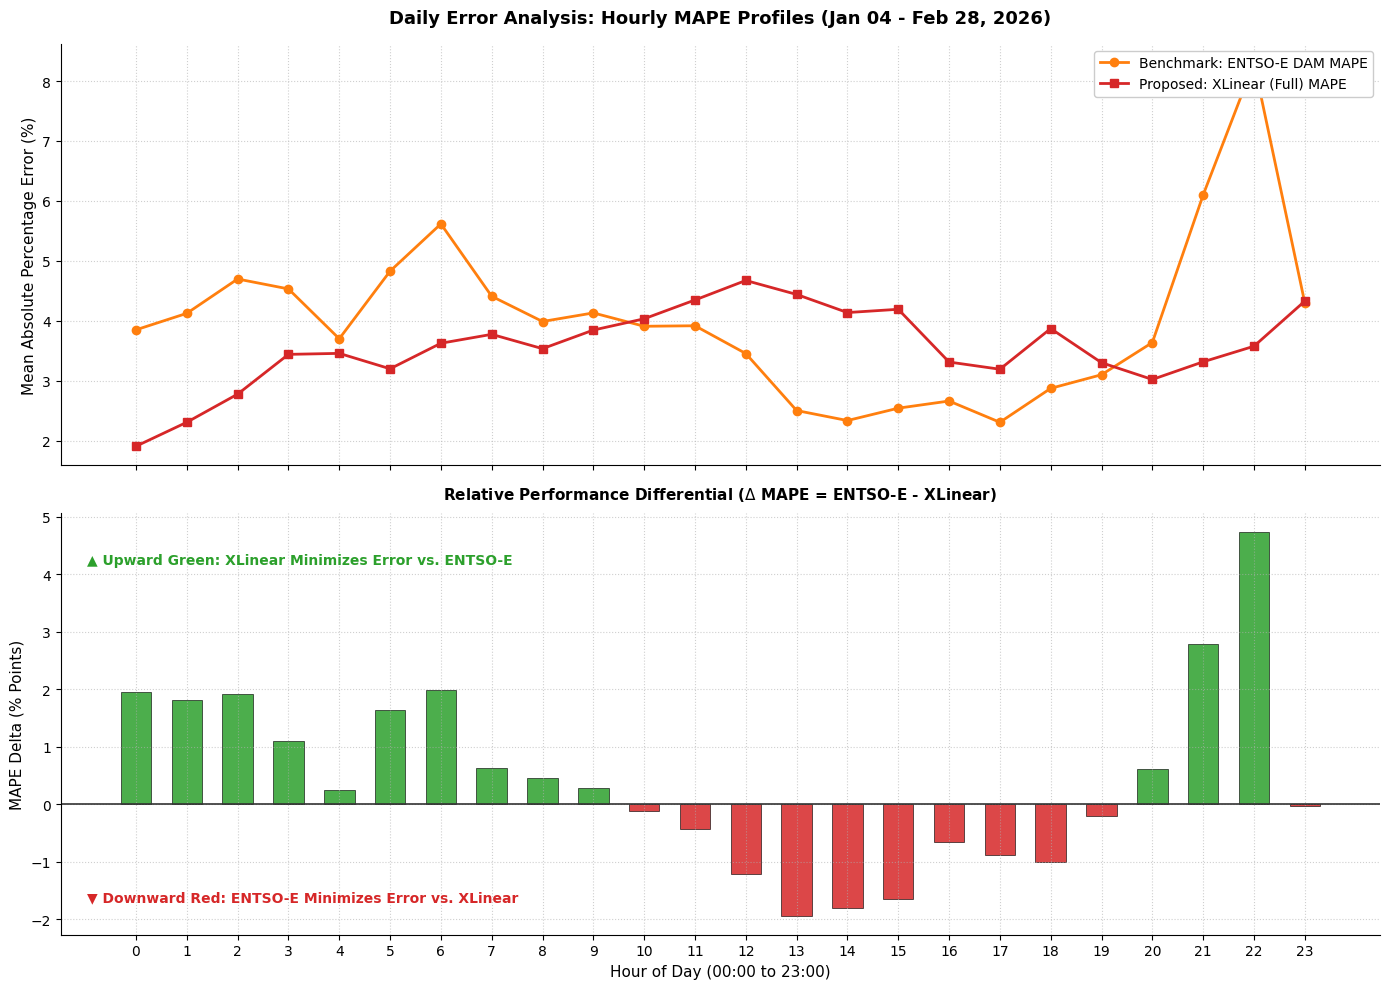

In [ ]:
# Hour of the day from the naive local timeline
df_eval['hour'] = df_eval['ds'].dt.hour

# Compute APE
df_eval['APE_XLinear'] = np.abs((df_eval['Actual_Load'] - df_eval['XLinear_Full']) / df_eval['Actual_Load']) * 100
df_eval['APE_ENTSOE'] = np.abs((df_eval['Actual_Load'] - df_eval['ENTSOE_Forecast']) / df_eval['Actual_Load']) * 100

# group by hour
hourly_metrics = df_eval.groupby('hour').agg({
    'APE_XLinear': 'mean',
    'APE_ENTSOE': 'mean'
}).reset_index()

hourly_metrics.rename(columns={'APE_XLinear': 'MAPE_XLinear', 'APE_ENTSOE': 'MAPE_ENTSOE'}, inplace=True)

# Calculate diff
hourly_metrics['Differential'] = hourly_metrics['MAPE_ENTSOE'] - hourly_metrics['MAPE_XLinear']

# Dual-Panel Visual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- UPPER PANEL: Daily Profile Comparison ---
ax1.plot(hourly_metrics['hour'], hourly_metrics['MAPE_ENTSOE'], 
         label='Benchmark: ENTSO-E DAM MAPE', color='#ff7f0e', marker='o', linewidth=2, zorder=3)
ax1.plot(hourly_metrics['hour'], hourly_metrics['MAPE_XLinear'], 
         label='Proposed: XLinear (Full) MAPE', color='#d62728', marker='s', linewidth=2, zorder=4)

ax1.set_title('Daily Error Analysis: Hourly MAPE Profiles (Jan 04 - Feb 28, 2026)', fontsize=13, weight='bold', pad=15)
ax1.set_ylabel('Mean Absolute Percentage Error (%)', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, framealpha=1.0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- LOWER PANEL: Performance Differential ---
# directional color masks
colors = ['#2ca02c' if diff >= 0 else '#d62728' for diff in hourly_metrics['Differential']]

ax2.bar(hourly_metrics['hour'], hourly_metrics['Differential'], 
        color=colors, alpha=0.85, edgecolor='black', linewidth=0.5, width=0.6)

# Rigid 0-baseline delimiter
ax2.axhline(0, color='#333333', linewidth=1.2, linestyle='-')

ax2.set_title('Relative Performance Differential ($\Delta$ MAPE = ENTSO-E - XLinear)', fontsize=11, weight='bold', pad=10)
ax2.set_xlabel('Hour of Day (00:00 to 23:00)', fontsize=11)
ax2.set_ylabel('MAPE Delta (% Points)', fontsize=11)
ax2.set_xticks(range(24))
ax2.grid(True, linestyle=':', alpha=0.6)

# contextual tags
ax2.text(0.02, 0.88, '▲ Upward Green: XLinear Minimizes Error vs. ENTSO-E', 
         transform=ax2.transAxes, color='#2ca02c', fontsize=10, weight='bold')
ax2.text(0.02, 0.08, '▼ Downward Red: ENTSO-E Minimizes Error vs. XLinear', 
         transform=ax2.transAxes, color='#d62728', fontsize=10, weight='bold')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()

# export
output_img = 'hourly_mape_up_below_comparison.png'
plt.savefig(output_img, dpi=300, bbox_inches='tight')

In [ ]:
# Extract the local physical date from the synchronized dataset
df_eval['date'] = df_eval['ds'].dt.date

# daily metric calculator for ENTSO-E columns
def calculate_entsoe_daily_errors(df_day):
    
    valid_slice = df_day.dropna(subset=['Actual_Load', 'ENTSOE_Forecast'])
    
    if len(valid_slice) == 0:
        return pd.Series({'MAE_MW': np.nan, 'RMSE_MW': np.nan, 'MAPE_%': np.nan})
        
    y_true = valid_slice['Actual_Load']
    y_pred = valid_slice['ENTSOE_Forecast']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return pd.Series({
        'MAE_MW': np.round(mae, 2),
        'RMSE_MW': np.round(rmse, 2),
        'MAPE_%': np.round(mape, 3),
        'Hours_Logged': int(len(valid_slice))
    })

# daily aggregations
entsoe_daily_perf = df_eval.groupby('date').apply(calculate_entsoe_daily_errors).reset_index()

# sort descending
top_10_worst_entsoe = entsoe_daily_perf.sort_values(by='MAPE_%', ascending=False).head(10)

top_10_worst_entsoe = top_10_worst_entsoe.reset_index(drop=True)

print("--- Top 10 Worst Performing Days for ENTSO-E (Day-Ahead Market) ---")
print(top_10_worst_entsoe.to_string(index=False))

--- Top 10 Worst Performing Days for ENTSO-E (Day-Ahead Market) ---
      date  MAE_MW  RMSE_MW  MAPE_%  Hours_Logged
2026-01-04  405.91   490.93  13.588          24.0
2026-01-14  383.11   421.10  11.434          24.0
2026-01-05  306.35   366.32   8.782          24.0
2026-01-06  295.72   348.79   8.277          24.0
2026-01-15  262.97   351.54   7.948          24.0
2026-01-13  258.06   334.40   7.867          24.0
2026-01-26  278.78   323.32   7.829          24.0
2026-01-09  258.56   315.15   7.455          24.0
2026-01-12  260.41   299.34   7.335          24.0
2026-01-16  241.55   328.44   7.073          24.0


In [12]:
# ENTSO-E outlier dates
entsoe_outlier_dates = pd.to_datetime([
    '2026-01-04', 
    '2026-01-14', 
    '2026-01-05', 
    '2026-01-06', 
    '2026-01-15'
]).date

# Ensure the 'date' column exists in your active evaluation slice
if 'date' not in df_eval.columns:
    df_eval['date'] = df_eval['ds'].dt.date

# exclude 5 outlier dates
cleaned_df_eval = df_eval[~df_eval['date'].isin(entsoe_outlier_dates)].copy()

# filter for GT and ENTSOE
valid_data_clean = cleaned_df_eval.dropna(subset=['Actual_Load', 'ENTSOE_Forecast'])

y_true_clean = valid_data_clean['Actual_Load']
y_pred_clean = valid_data_clean['ENTSOE_Forecast']

# calculate metrics
mae_clean = mean_absolute_error(y_true_clean, y_pred_clean)
rmse_clean = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mape_clean = mean_absolute_percentage_error(y_true_clean, y_pred_clean) * 100

# output results
removed_hours = len(df_eval.dropna(subset=['Actual_Load', 'ENTSOE_Forecast'])) - len(valid_data_clean)
print(f"ENTSO-E Evaluation (Excluding {len(entsoe_outlier_dates)} Outlier Days)")
print("-" * 65)
print(f"Clean MAE:  {mae_clean:.2f} MW")
print(f"Clean RMSE: {rmse_clean:.2f} MW")
print(f"Clean MAPE: {mape_clean:.3f} %")

ENTSO-E Evaluation (Excluding 5 Outlier Days)
-----------------------------------------------------------------
Clean MAE:  115.41 MW
Clean RMSE: 172.68 MW
Clean MAPE: 3.401 %


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Ensure the localized physical date column is present
df_eval['date'] = df_eval['ds'].dt.date

# daily metric calculator for the XLinear columns
def calculate_xlinear_daily_errors(df_day):

    valid_slice = df_day.dropna(subset=['Actual_Load', 'XLinear_Full'])
    
    if len(valid_slice) == 0:
        return pd.Series({'MAE_MW': np.nan, 'RMSE_MW': np.nan, 'MAPE_%': np.nan, 'Hours_Logged': 0})
        
    y_true = valid_slice['Actual_Load']
    y_pred = valid_slice['XLinear_Full']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return pd.Series({
        'MAE_MW': np.round(mae, 2),
        'RMSE_MW': np.round(rmse, 2),
        'MAPE_%': np.round(mape, 3),
        'Hours_Logged': int(len(valid_slice))
    })

# daily aggregations for XLinear
xlinear_daily_perf = df_eval.groupby('date').apply(calculate_xlinear_daily_errors).reset_index()

# sort descending
top_10_worst_xlinear = xlinear_daily_perf.sort_values(by='MAPE_%', ascending=False).head(10)
top_10_worst_xlinear = top_10_worst_xlinear.reset_index(drop=True)

print("--- Top 10 Worst Performing Days for XLinear Full (Day-Ahead Market) ---")
print(top_10_worst_xlinear.to_string(index=False))

--- Top 10 Worst Performing Days for XLinear Full (Day-Ahead Market) ---
      date  MAE_MW  RMSE_MW  MAPE_%  Hours_Logged
2026-02-15  623.50   660.20  24.246          24.0
2026-02-17  520.37   599.11  14.180          24.0
2026-02-16  303.02   335.41  10.413          24.0
2026-01-05  309.22   347.01   8.502          24.0
2026-02-14  199.27   274.24   7.064          24.0
2026-01-24  200.32   206.86   6.257          24.0
2026-02-27  138.61   156.92   4.600          24.0
2026-01-14  144.70   162.07   4.353          24.0
2026-02-13  139.11   174.64   4.289          24.0
2026-02-04  169.80   184.84   4.232          24.0


In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# XLinear outlier dates
xlinear_outlier_dates = pd.to_datetime([
    '2026-02-15', 
    '2026-02-17', 
    '2026-02-16', 
    '2026-01-05', 
    '2026-02-14'
]).date

# Ensure the 'date' column is present in the dataframe
if 'date' not in df_eval.columns:
    df_eval['date'] = df_eval['ds'].dt.date

# exclude the 5 outlier dates
cleaned_df_eval_xl = df_eval[~df_eval['date'].isin(xlinear_outlier_dates)].copy()

# filter for GT and XLinear output
valid_data_clean_xl = cleaned_df_eval_xl.dropna(subset=['Actual_Load', 'XLinear_Full'])

y_true_clean_xl = valid_data_clean_xl['Actual_Load']
y_pred_clean_xl = valid_data_clean_xl['XLinear_Full']

# calculate metrics
mae_clean_xl = mean_absolute_error(y_true_clean_xl, y_pred_clean_xl)
rmse_clean_xl = np.sqrt(mean_squared_error(y_true_clean_xl, y_pred_clean_xl))
mape_clean_xl = mean_absolute_percentage_error(y_true_clean_xl, y_pred_clean_xl) * 100

# output
removed_hours_xl = len(df_eval.dropna(subset=['Actual_Load', 'XLinear_Full'])) - len(valid_data_clean_xl)
print(f"--- XLinear Evaluation (Excluding {len(xlinear_outlier_dates)} Outlier Days) ---")
print("-" * 65)
print(f"Clean MAE:  {mae_clean_xl:.2f} MW")
print(f"Clean RMSE: {rmse_clean_xl:.2f} MW")
print(f"Clean MAPE: {mape_clean_xl:.3f} %")

--- XLinear Evaluation (Excluding 5 Outlier Days) ---
-----------------------------------------------------------------
Clean MAE:  90.30 MW
Clean RMSE: 113.02 MW
Clean MAPE: 2.652 %
